# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter.

In [ ]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
import os
datadir = "/content/assignment3"
if not os.path.exists(datadir):
  !ln -s "/content/drive/My Drive/assignment3_sp25/" $datadir # TODO: Fill your assignment3 path
os.chdir(datadir)
!pwd

/content/drive/My Drive/assignment3_sp25


# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random


def rotate_img(img, rot):
    if rot == 0: # 0 degrees rotation
        return img
    # TODO: Implement rotate_img() - return the rotated img
    elif rot == 1:
        return transforms.functional.rotate(img, 90)
    elif rot == 2:
        return transforms.functional.rotate(img, 180)
    elif rot == 3:
        return transforms.functional.rotate(img, 270)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


class CIFAR10Rotation(torchvision.datasets.CIFAR10):

    def __init__(self, root, train, download, transform) -> None:
        super().__init__(root=root, train=train, download=download, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index: int):
        image, cls_label = super().__getitem__(index)

        # randomly select image rotation
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)

        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, torch.tensor(cls_label).long()

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 128

trainset = CIFAR10Rotation(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = CIFAR10Rotation(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

Show some example images and rotated images with labels:

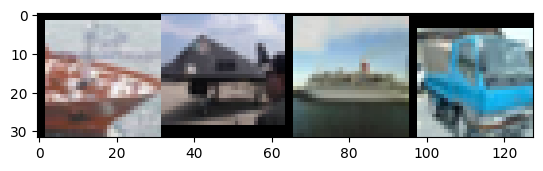

Class labels:  ship  plane ship  truck


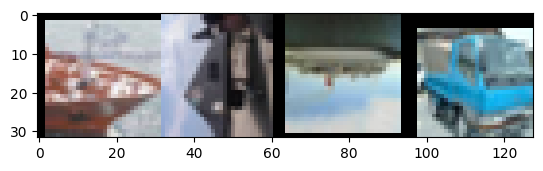

Rotation labels:  0     90    180   0    


In [ ]:
import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [ ]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [ ]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

## 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task):

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)
            else:
                raise ValueError("Unknown task specified!")

            # TODO: Zero the parameter gradients
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


            # TODO: Get predicted results
            _, predicted = torch.max(outputs, 1)

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)
        net.train()

    print('Finished Training')

In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.001, task='rotation')

# TODO: Save the model
torch.save(net.state_dict(), 'model_rotation.pth')

[1,   100] loss: 1.262 acc: 43.73 time: 10.41
[1,   200] loss: 1.135 acc: 50.27 time: 8.78
[1,   300] loss: 1.121 acc: 51.16 time: 8.71
TESTING:
Accuracy of the network on the 10000 test images: 56.92 %
Average loss on the 10000 test images: 1.015
[2,   100] loss: 1.038 acc: 56.13 time: 8.68
[2,   200] loss: 1.014 acc: 56.73 time: 8.76
[2,   300] loss: 1.014 acc: 57.04 time: 8.75
TESTING:
Accuracy of the network on the 10000 test images: 59.11 %
Average loss on the 10000 test images: 0.967
[3,   100] loss: 0.981 acc: 58.45 time: 8.86
[3,   200] loss: 0.955 acc: 60.08 time: 8.76
[3,   300] loss: 0.951 acc: 60.21 time: 8.73
TESTING:
Accuracy of the network on the 10000 test images: 62.86 %
Average loss on the 10000 test images: 0.905
[4,   100] loss: 0.917 acc: 61.46 time: 8.79
[4,   200] loss: 0.911 acc: 62.13 time: 8.78
[4,   300] loss: 0.918 acc: 61.98 time: 8.77
TESTING:
Accuracy of the network on the 10000 test images: 62.10 %
Average loss on the 10000 test images: 0.920
[5,   100] 

## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
pretrained_path = 'model_rotation.pth'
num_classes = 10
net = resnet18(pretrained=False)
net.fc = nn.Linear(net.fc.in_features, 4)
net.load_state_dict(torch.load(pretrained_path))
net.fc = nn.Linear(net.fc.in_features, num_classes)
net = net.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
for name, param in net.named_parameters():
    if not (name.startswith('layer4') or name.startswith('fc')):
        param.requires_grad = False

In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')
torch.save(net.state_dict(), 'pretrained_classfication.pth')


[1,   100] loss: 1.701 acc: 40.70 time: 8.54
[1,   200] loss: 1.433 acc: 48.67 time: 8.44
[1,   300] loss: 1.374 acc: 50.66 time: 8.36
TESTING:
Accuracy of the network on the 10000 test images: 52.65 %
Average loss on the 10000 test images: 1.507
[2,   100] loss: 1.303 acc: 52.62 time: 8.33
[2,   200] loss: 1.275 acc: 54.17 time: 8.31
[2,   300] loss: 1.267 acc: 54.81 time: 8.37
TESTING:
Accuracy of the network on the 10000 test images: 54.65 %
Average loss on the 10000 test images: 1.277
[3,   100] loss: 1.227 acc: 55.95 time: 8.38
[3,   200] loss: 1.216 acc: 56.10 time: 8.36
[3,   300] loss: 1.207 acc: 56.42 time: 8.50
TESTING:
Accuracy of the network on the 10000 test images: 57.68 %
Average loss on the 10000 test images: 1.198
[4,   100] loss: 1.199 acc: 56.92 time: 8.40
[4,   200] loss: 1.200 acc: 56.38 time: 8.44
[4,   300] loss: 1.186 acc: 57.62 time: 8.37
TESTING:
Accuracy of the network on the 10000 test images: 57.92 %
Average loss on the 10000 test images: 1.178
[5,   100] l

## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(pretrained=False,num_classes=10)
net = net.to(device)

/Users/yutaorao/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.
for name, param in net.named_parameters():
    if not (name.startswith('layer4') or name.startswith('fc')):
        param.requires_grad = False

In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

[1,   100] loss: 2.224 acc: 24.62 time: 10.55
[1,   200] loss: 1.960 acc: 30.77 time: 9.38
[1,   300] loss: 1.906 acc: 31.09 time: 9.11
TESTING:
Accuracy of the network on the 10000 test images: 37.25 %
Average loss on the 10000 test images: 1.737
[2,   100] loss: 1.807 acc: 33.88 time: 9.48
[2,   200] loss: 1.796 acc: 35.00 time: 9.21
[2,   300] loss: 1.788 acc: 35.39 time: 9.18
TESTING:
Accuracy of the network on the 10000 test images: 39.71 %
Average loss on the 10000 test images: 1.683
[3,   100] loss: 1.762 acc: 36.35 time: 10.80
[3,   200] loss: 1.757 acc: 36.72 time: 11.05
[3,   300] loss: 1.757 acc: 36.48 time: 9.65
TESTING:
Accuracy of the network on the 10000 test images: 40.35 %
Average loss on the 10000 test images: 1.656
[4,   100] loss: 1.735 acc: 37.50 time: 9.09
[4,   200] loss: 1.735 acc: 37.35 time: 10.92
[4,   300] loss: 1.727 acc: 37.80 time: 9.17
TESTING:
Accuracy of the network on the 10000 test images: 41.37 %
Average loss on the 10000 test images: 1.636
[5,   10

## 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
pretrained_path = 'model_rotation.pth'
num_classes = 10
net = resnet18(pretrained=False)
net.fc = nn.Linear(net.fc.in_features, 4)
net.load_state_dict(torch.load(pretrained_path))
net.fc = nn.Linear(net.fc.in_features, num_classes)
net = net.to(device)

In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

In [ ]:
train(net, criterion, optimizer, num_epochs=15, decay_epochs=10, init_lr=0.01, task='classification')
torch.save(net.state_dict(), 'full_model_classfication.pth')

[1,   100] loss: 1.930 acc: 29.52 time: 8.84
[1,   200] loss: 1.589 acc: 40.59 time: 8.84
[1,   300] loss: 1.501 acc: 45.23 time: 8.85
TESTING:
Accuracy of the network on the 10000 test images: 44.51 %
Average loss on the 10000 test images: 1.679
[2,   100] loss: 1.351 acc: 51.67 time: 8.73
[2,   200] loss: 1.233 acc: 55.66 time: 8.80
[2,   300] loss: 1.185 acc: 57.41 time: 8.76
TESTING:
Accuracy of the network on the 10000 test images: 59.11 %
Average loss on the 10000 test images: 1.159
[3,   100] loss: 1.075 acc: 62.09 time: 8.84
[3,   200] loss: 1.042 acc: 62.84 time: 8.74
[3,   300] loss: 1.011 acc: 64.20 time: 8.89
TESTING:
Accuracy of the network on the 10000 test images: 65.35 %
Average loss on the 10000 test images: 1.010
[4,   100] loss: 0.927 acc: 67.28 time: 8.82
[4,   200] loss: 0.942 acc: 66.91 time: 8.77
[4,   300] loss: 0.921 acc: 67.90 time: 8.75
TESTING:
Accuracy of the network on the 10000 test images: 69.97 %
Average loss on the 10000 test images: 0.893
[5,   100] l

## 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=10, pretrained=False)
net = net.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

[1,   100] loss: 2.216 acc: 22.45 time: 11.04
[1,   200] loss: 1.843 acc: 32.65 time: 10.94
[1,   300] loss: 1.701 acc: 37.62 time: 10.92
TESTING:
Accuracy of the network on the 10000 test images: 41.30 %
Average loss on the 10000 test images: 1.591
[2,   100] loss: 1.568 acc: 42.43 time: 10.83
[2,   200] loss: 1.475 acc: 46.02 time: 10.59
[2,   300] loss: 1.391 acc: 49.27 time: 10.78
TESTING:
Accuracy of the network on the 10000 test images: 53.13 %
Average loss on the 10000 test images: 1.298
[3,   100] loss: 1.263 acc: 54.46 time: 10.82
[3,   200] loss: 1.201 acc: 56.96 time: 10.85
[3,   300] loss: 1.191 acc: 56.94 time: 10.93
TESTING:
Accuracy of the network on the 10000 test images: 61.40 %
Average loss on the 10000 test images: 1.107
[4,   100] loss: 1.093 acc: 60.88 time: 11.38
[4,   200] loss: 1.072 acc: 61.91 time: 10.88
[4,   300] loss: 1.033 acc: 63.20 time: 10.80
TESTING:
Accuracy of the network on the 10000 test images: 66.37 %
Average loss on the 10000 test images: 0.964


### Part 4a Rotation Improvement

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import resnet18

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

net = resnet18(num_classes=4)
net = net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

num_epochs = 70
steps_per_epoch = len(trainloader)
total_steps = num_epochs * steps_per_epoch

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

def schedule_train(net, criterion, optimizer, scheduler, num_epochs, task):
    import time
    for epoch in range(num_epochs):
        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()
        net.train()
        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)
            else:
                raise ValueError("Unknown task specified!")
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()
            print_freq = 100
            if i % print_freq == (print_freq - 1):
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100 * running_correct / running_total:.2f}% time: {time.time() - start_time:.2f}s')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()
        net.eval()
        run_test(net, testloader, criterion, task)
        net.train()
    print('Finished Training')

schedule_train(net, criterion, optimizer, scheduler, num_epochs=num_epochs, task='rotation')
torch.save(net.state_dict(), 'model_rotation_oncycle.pth')


[1,   100] loss: 1.278 acc: 42.04% time: 8.91s
[1,   200] loss: 1.139 acc: 50.19% time: 8.81s
[1,   300] loss: 1.102 acc: 52.83% time: 8.85s
TESTING:
Accuracy of the network on the 10000 test images: 53.02 %
Average loss on the 10000 test images: 1.236
[2,   100] loss: 1.052 acc: 55.70% time: 8.76s
[2,   200] loss: 1.024 acc: 56.68% time: 8.77s
[2,   300] loss: 1.024 acc: 56.44% time: 8.84s
TESTING:
Accuracy of the network on the 10000 test images: 59.87 %
Average loss on the 10000 test images: 0.952
[3,   100] loss: 0.982 acc: 58.75% time: 8.78s
[3,   200] loss: 0.964 acc: 59.41% time: 8.74s
[3,   300] loss: 0.957 acc: 59.63% time: 8.87s
TESTING:
Accuracy of the network on the 10000 test images: 60.87 %
Average loss on the 10000 test images: 0.934
[4,   100] loss: 0.935 acc: 60.77% time: 8.75s
[4,   200] loss: 0.911 acc: 61.92% time: 8.77s
[4,   300] loss: 0.913 acc: 61.98% time: 8.79s
TESTING:
Accuracy of the network on the 10000 test images: 62.95 %
Average loss on the 10000 test im

### Part 4b Classification Improvement

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import resnet18

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

net = resnet18(num_classes=10, pretrained=False)
net = net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 70
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

def train(net, criterion, optimizer, scheduler, num_epochs, task):
    import time
    for epoch in range(num_epochs):
        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()
        net.train()
        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)
            else:
                raise ValueError("Unknown task specified!")
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()
            print_freq = 100
            if i % print_freq == (print_freq - 1):
                print(f'[{epoch+1}, {i+1:5d}] loss: {running_loss/print_freq:.3f} acc: {100*running_correct/running_total:.2f}% time: {time.time()-start_time:.2f}s')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()
        scheduler.step()
        net.eval()
        run_test(net, testloader, criterion, task)
        net.train()
    print('Finished Training')

train(net, criterion, optimizer, scheduler, num_epochs=num_epochs, task='classification')
torch.save(net.state_dict(), 'Advance_resnet18_Classification.pth')


[1,   100] loss: 1.830 acc: 33.21% time: 8.79s
[1,   200] loss: 1.564 acc: 42.21% time: 8.79s
[1,   300] loss: 1.433 acc: 47.73% time: 8.83s
TESTING:
Accuracy of the network on the 10000 test images: 48.65 %
Average loss on the 10000 test images: 1.469
[2,   100] loss: 1.267 acc: 54.29% time: 8.77s
[2,   200] loss: 1.180 acc: 57.84% time: 8.84s
[2,   300] loss: 1.136 acc: 59.43% time: 8.83s
TESTING:
Accuracy of the network on the 10000 test images: 62.50 %
Average loss on the 10000 test images: 1.083
[3,   100] loss: 1.047 acc: 62.98% time: 8.69s
[3,   200] loss: 1.019 acc: 63.73% time: 8.78s
[3,   300] loss: 1.012 acc: 64.26% time: 8.91s
TESTING:
Accuracy of the network on the 10000 test images: 67.28 %
Average loss on the 10000 test images: 0.943
[4,   100] loss: 0.946 acc: 66.61% time: 8.92s
[4,   200] loss: 0.922 acc: 67.19% time: 8.81s
[4,   300] loss: 0.901 acc: 67.88% time: 8.82s
TESTING:
Accuracy of the network on the 10000 test images: 68.21 %
Average loss on the 10000 test im

## Extra Credit

In [ ]:
import torch
from torch.utils.data import Subset

def get_subset(dataset, samples_per_class, num_classes=10):
    indices = []
    count_per_class = {i: 0 for i in range(num_classes)}
    for i, data in enumerate(dataset):
        label = data[-1]
        if torch.is_tensor(label):
            label = label.item()
        if count_per_class[label] < samples_per_class:
            indices.append(i)
            count_per_class[label] += 1
        if all(count >= samples_per_class for count in count_per_class.values()):
            break

    return Subset(dataset, indices)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_subset(dataset, samples_per_class, num_classes=10):
    indices = []
    count_per_class = {i: 0 for i in range(num_classes)}
    for i, data in enumerate(dataset):
        label = data[-1]
        if torch.is_tensor(label):
            label = label.item()
        if count_per_class[label] < samples_per_class:
            indices.append(i)
            count_per_class[label] += 1
        if all(count >= samples_per_class for count in count_per_class.values()):
            break
    return Subset(dataset, indices)

def evaluate(net, dataloader,criterion,task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    return 100 * correct / total

criterion = nn.CrossEntropyLoss()
num_epochs = 10
decay_epochs = 30
init_lr = 0.001

shots = [10, 20, 50, 100,200,500,1000,5000]
acc_supervised = []
acc_rotnet = []

for shot in shots:
    subset_train = get_subset(trainset, samples_per_class=shot)
    trainloader = DataLoader(subset_train, batch_size=64, shuffle=True, num_workers=2)

    model_sup = resnet18(pretrained=False)
    model_sup.fc = nn.Linear(model_sup.fc.in_features, 10)
    model_sup = model_sup.to(device)
    optimizer_sup = optim.Adam(model_sup.parameters(), lr=0.01)
    train(model_sup, criterion, optimizer_sup, num_epochs, decay_epochs, init_lr,task="classification")
    sup_acc = evaluate(model_sup, testloader,criterion,task="classification")
    acc_supervised.append(sup_acc)

    model_ft = resnet18(pretrained=False)
    model_ft.fc = nn.Linear(model_ft.fc.in_features, 4)
    model_ft.load_state_dict(torch.load("model_rotation.pth"))
    model_ft.fc = nn.Linear(model_ft.fc.in_features, 10)
    model_ft = model_ft.to(device)
    optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.01)
    train(model_ft, criterion, optimizer_ft, num_epochs, decay_epochs, init_lr,task="classification")
    ft_acc = evaluate(model_ft, testloader,criterion,task="classification")
    acc_rotnet.append(ft_acc)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


TESTING:
Accuracy of the network on the 10000 test images: 12.75 %
Average loss on the 10000 test images: 2.317
TESTING:
Accuracy of the network on the 10000 test images: 15.45 %
Average loss on the 10000 test images: 2.339
TESTING:
Accuracy of the network on the 10000 test images: 18.74 %
Average loss on the 10000 test images: 2.360
TESTING:
Accuracy of the network on the 10000 test images: 14.63 %
Average loss on the 10000 test images: 2.975
TESTING:
Accuracy of the network on the 10000 test images: 14.73 %
Average loss on the 10000 test images: 3.867
TESTING:
Accuracy of the network on the 10000 test images: 16.63 %
Average loss on the 10000 test images: 4.479
TESTING:
Accuracy of the network on the 10000 test images: 16.88 %
Average loss on the 10000 test images: 5.045
TESTING:
Accuracy of the network on the 10000 test images: 17.90 %
Average loss on the 10000 test images: 5.315
TESTING:
Accuracy of the network on the 10000 test images: 20.27 %
Average loss on the 10000 test images

Shots: [10, 20, 50, 100, 200, 500, 1000, 5000]
Supervised Accuracies: [23.14, 26.24, 35.2, 39.61, 45.87, 50.93, 63.31, 74.83]
RotNet Fine-tuned Accuracies: [30.21, 36.18, 47.88, 53.85, 59.5, 66.28, 70.96, 79.0]


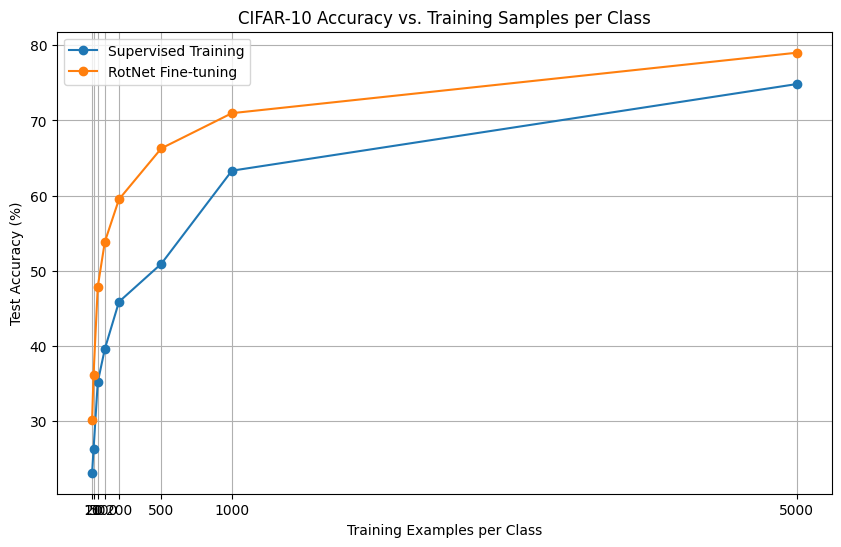

In [ ]:
print("Shots:", shots)
print("Supervised Accuracies:", acc_supervised)
print("RotNet Fine-tuned Accuracies:", acc_rotnet)

plt.figure(figsize=(10, 6))
plt.plot(shots, acc_supervised, label='Supervised Training', marker='o', linestyle='-')
plt.plot(shots, acc_rotnet, label='RotNet Fine-tuning', marker='o', linestyle='-')
plt.xticks(shots)
plt.xlabel("Training Examples per Class")
plt.ylabel("Test Accuracy (%)")
plt.title("CIFAR-10 Accuracy vs. Training Samples per Class")
plt.legend()
plt.grid(True)
plt.savefig("cifar10_fewshot_comparison.png", dpi=300, bbox_inches='tight')
plt.show()